Дорогой студент!

В домашнем задании Ultra Pro занятия по обработке тектсов с помощью НС мы ставим задачу распознать уже не 6, как ранее, а целых 20 русских писателей! Это подразумевает и больший размер базы для обучения соответственно. Ячейка для скачивания базы уже включена в ноутбук задания.


 В задании необходимо выполнить следующие пункты:

  1. Загрузить саму базу по ссылке и подговить файлы базы для обработки.
  2. Создать обучающую и проверочную выборки, обратив особое внимание на балансировку базы: количество примеров каждого класса должно быть примерно одного порядка. При этом для разбивки необходимо применить цикл. Проверочная выборка должна быть 20% от общей выборки.
  3. Подготовьте выборки для обучения и обучите сеть. Добейтесь результата точности сети не менее 95% на проверочной выборке модели Bag of Words и 75-80% - для модели Embedding.
   


## Загрузка данных

In [2]:
# Работа с массивами данных
import numpy as np

# Работа с таблицами
import pandas as pd


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Отрисовка графиков
import matplotlib.pyplot as plt


# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D,  Embedding,  GlobalAveragePooling1D

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

from sklearn.preprocessing import LabelEncoder

# Заполнение последовательностей до определенной длины
from tensorflow.keras.preprocessing.sequence import pad_sequences


from sklearn.model_selection import train_test_split


# Для работы с файлами в Colaboratory
import os


# Отрисовка графиков
import matplotlib.pyplot as plt

import tensorflow as tf

%matplotlib inline

In [3]:
import gdown                                      # Подключим функцию gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip', None, quiet=True)      # Скачивание файла

'20writers.zip'

## Распаковка архива

In [4]:
# Распаковка архива в папку writers
!unzip -qo 20writers.zip -d writers/

# Просмотр содержимого папки
!ls writers

Беляев.txt    Гончаров.txt     Каверин.txt    Лесков.txt     Толстой.txt
Булгаков.txt  Горький.txt      Катаев.txt     Носов.txt      Тургенев.txt
Васильев.txt  Грибоедов.txt    Куприн.txt     Пастернак.txt  Чехов.txt
Гоголь.txt    Достоевский.txt  Лермонтов.txt  Пушкин.txt     Шолохов.txt


In [25]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'                     # Папка с текстовыми файлами


# Задание параметров преобразования
VOCAB_SIZE = 10000                        # Объем словаря для токенизатора
WIN_SIZE   = 1500                         # Длина отрезка текста (окна) в словах
WIN_HOP    = 500
MAX_LEN = 500

BATCH_SIZE = 64                # Шаг окна разбиения текста на векторы


In [6]:

files = os.listdir(FILE_DIR)
print(files)
print("Количество авторов:", len(files))

['Васильев.txt', 'Горький.txt', 'Гоголь.txt', 'Носов.txt', 'Лермонтов.txt', 'Достоевский.txt', 'Лесков.txt', 'Шолохов.txt', 'Катаев.txt', 'Куприн.txt', 'Чехов.txt', 'Пушкин.txt', 'Грибоедов.txt', 'Беляев.txt', 'Тургенев.txt', 'Толстой.txt', 'Пастернак.txt', 'Гончаров.txt', 'Каверин.txt', 'Булгаков.txt']
Количество авторов: 20


## Разделение текста на куски

In [7]:
data = []

for file_name in os.listdir(FILE_DIR):
    if not file_name.endswith('.txt'):
        continue

    author = file_name.replace('.txt', '')
    file_path = os.path.join(FILE_DIR, file_name)

    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read().replace('\n', ' ')

    for i in range(0, len(text) - WIN_SIZE, WIN_HOP):
        chunk = text[i:i + WIN_SIZE]

        data.append({
            'author': author,
            'text': chunk
        })

df = pd.DataFrame(data)

print("Размер:", df.shape)
print(df.columns)
display(df['author'].value_counts())

Размер: (112367, 2)
Index(['author', 'text'], dtype='object')


,count
author,
Чехов,13221
Достоевский,10355
Пушкин,6814
Шолохов,6770
Толстой,6712
Гончаров,6207
Пастернак,6176
Васильев,5903
Катаев,5156


## Балансировка классов

In [8]:
MIN_SAMPLES = df['author'].value_counts().min()

df_balanced = (
    df.groupby('author')
    .apply(lambda x: x.sample(MIN_SAMPLES, random_state=42))
    .reset_index(drop=True)
)

df_balanced['author'].value_counts()

/tmp/ipykernel_1440/637550002.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(MIN_SAMPLES, random_state=42))


,count
author,
Беляев,1936
Булгаков,1936
Васильев,1936
Гоголь,1936
Гончаров,1936
Горький,1936
Грибоедов,1936
Достоевский,1936
Каверин,1936


## Разделение данных на обучающую и тестовую выборки

In [9]:
train_df, test_df = train_test_split(
    df_balanced,
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['author'])

display(train_df['author'].value_counts())
display(test_df['author'].value_counts())

,count
author,
Булгаков,1549
Лесков,1549
Катаев,1549
Пушкин,1549
Гончаров,1549
Горький,1549
Тургенев,1549
Чехов,1549
Беляев,1549


,count
author,
Пастернак,388
Достоевский,388
Грибоедов,388
Куприн,388
Беляев,387
Катаев,387
Лесков,387
Гоголь,387
Пушкин,387


## Кодирование авторов

In [10]:
le = LabelEncoder()

y_train = le.fit_transform(train_df['author'])
y_test = le.transform(test_df['author'])

## BOW

### Токенизация текстов

In [11]:
t = Tokenizer(
    num_words=VOCAB_SIZE,
    filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
    lower=True, split=' ',
    oov_token='неизвестное_слово',
    char_level=False)
t.fit_on_texts(train_df['text'])


### Преобразование текста в числа

In [12]:
x_train = t.texts_to_matrix(train_df['text'], mode='binary')
x_test = t.texts_to_matrix(test_df['text'], mode='binary')


In [13]:
def compile_model(model,
                    x_train,
                    y_train,
                    x_val,
                    y_val,
                    optimizer='adam',
                    epochs=50,
                    batch_size=BATCH_SIZE,):

    callback = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=5,
        restore_best_weights=True)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

    model.summary()

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        callbacks=[callback],
        verbose=1)

In [14]:
def plot_history(history, figsize=(12, 4)):
    plt.figure(figsize=figsize)

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Точность на обучении')
    plt.plot(history.history['val_accuracy'], label='Точность на валидации')
    plt.title('Точность модели')
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Потери на обучении')
    plt.plot(history.history['val_loss'], label='Потери на валидации')
    plt.title('Потери модели')
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [21]:
def eval_model(model, x, y_true, class_labels, title='', figsize=(40, 20)):

    y_pred = model.predict(x)

    y_pred_cls = np.argmax(y_pred, axis=1)
    y_true_cls = y_true

    acc = (y_pred_cls == y_true_cls).mean()

    cm = confusion_matrix(
        y_true_cls,
        y_pred_cls,
        labels=range(len(class_labels)),
        normalize='true'
    )

    cm_rounded = np.around(cm, 3)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'Confusion Matrix: {title}', fontsize=16)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_rounded,
        display_labels=class_labels
    )

    disp.plot(ax=ax, cmap='Blues')

    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print('-' * 80)
    print(f'Accuracy: {acc:.4f}')

    class_accuracy = np.diag(cm)

    for i, label in enumerate(class_labels):
        print(f"{label:<20} → {class_accuracy[i]:.4f}")

    print(f"\nMean class accuracy: {np.mean(class_accuracy):.4f}")

In [22]:
def compile_train_eval_model(
    model,
    x_train,
    y_train,
    x_test,
    y_test,
    class_labels,
    title='',
    optimizer='adam',
    epochs=50,
    batch_size=32,
    graph_size=(20, 5),
    cm_size=(10, 10)
):

    compile_model(
        model,
        x_train, y_train,
        x_test, y_test,
        optimizer=optimizer,
        epochs=epochs,
        batch_size=batch_size,
    )

    eval_model(
        model,
        x_test,
        y_test,
        class_labels=class_labels,
        title=title,
        figsize=cm_size
    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 20)             │         1,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,289,684 (4.92 MB)

 Trainable params: 1,289,684 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6141 - loss: 1.3139 - val_accuracy: 0.9393 - val_loss: 0.2557
Epoch 2/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8963 - loss: 0.3467 - val_accuracy: 0.9504 - val_loss: 0.1702
Epoch 3/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9410 - loss: 0.1942 - val_accuracy: 0.9540 - val_loss: 0.1474
Epoch 4/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9550 - loss: 0.1452 - val_accuracy: 0.9566 - val_loss: 0.1431
Epoch 5/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9629 - loss: 0.1176 - val_accuracy: 0.9557 - val_loss: 0.1422
Epoch 6/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9671 - loss: 0.1044 - val_accuracy: 0.9565 - val_loss: 0.1467
Epoch 7/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9703 - loss: 0.0959 - val_accuracy: 0.9574 - val_loss: 0.1437
Epoch 8/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9717 - loss: 0.0893 - val_accuracy: 

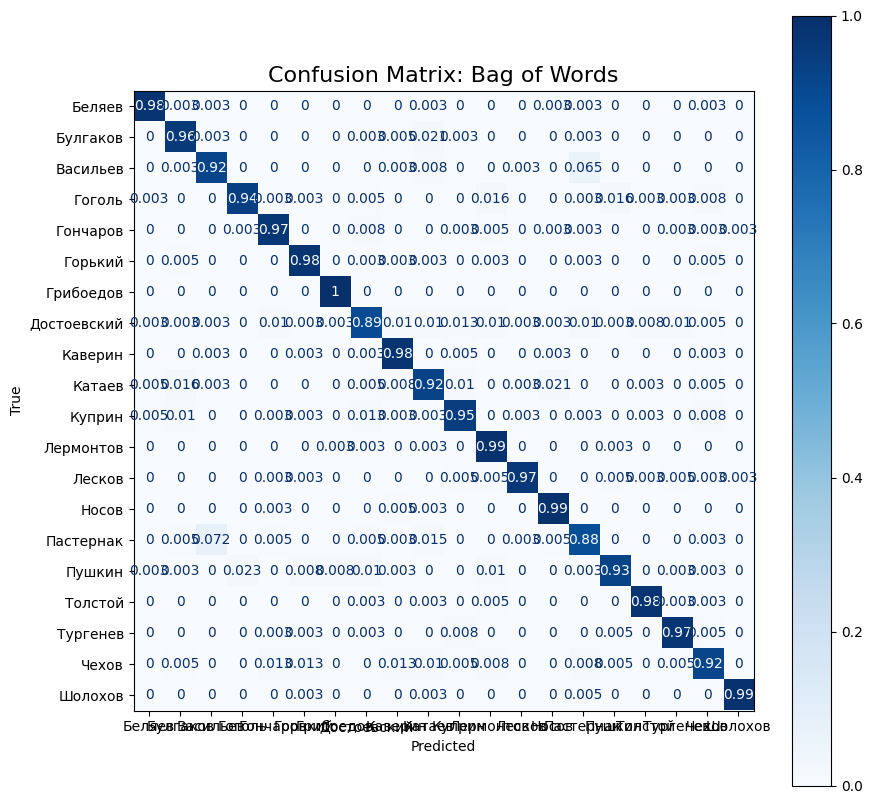

--------------------------------------------------------------------------------
Accuracy: 0.9557
Беляев               → 0.9845
Булгаков             → 0.9638
Васильев             → 0.9199
Гоголь               → 0.9406
Гончаров             → 0.9690
Горький              → 0.9767
Грибоедов            → 1.0000
Достоевский          → 0.8918
Каверин              → 0.9819
Катаев               → 0.9225
Куприн               → 0.9459
Лермонтов            → 0.9897
Лесков               → 0.9664
Носов                → 0.9897
Пастернак            → 0.8840
Пушкин               → 0.9251
Толстой              → 0.9845
Тургенев             → 0.9742
Чехов                → 0.9147
Шолохов              → 0.9897

Mean class accuracy: 0.9557


In [23]:
model_bow = Sequential([
    Dense(128, activation='relu', input_shape=(VOCAB_SIZE,)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

compile_train_eval_model(model_bow,
                         x_train, y_train,
                         x_test, y_test,
                         class_labels=le.classes_,
                         title='Bag of Words')

In [27]:
model_bow.save('model_bow_ultra_pro.keras')

## Эмбеддинг

In [26]:


X_train_seq = t.texts_to_sequences(train_df['text'])
X_test_seq = t.texts_to_sequences(test_df['text'])

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1005 - loss: 2.8949 - val_accuracy: 0.2450 - val_loss: 2.6010
Epoch 2/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3562 - loss: 2.1265 - val_accuracy: 0.5837 - val_loss: 1.5231
Epoch 3/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6161 - loss: 1.2686 - val_accuracy: 0.7429 - val_loss: 0.8975
Epoch 4/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7409 - loss: 0.8525 - val_accuracy: 0.8004 - val_loss: 0.6599
Epoch 5/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8078 - loss: 0.6259 - val_accuracy: 0.8440 - val_loss: 0.5189
Epoch 6/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8462 - loss: 0.4957 - val_accuracy: 0.8724 - val_loss: 0.4336
Epoch 7/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8728 - loss: 0.4073 - val_accuracy: 0.8811 - val_loss: 0.3718
Epoch 8/50
968/968 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8969 - loss: 0.3328 - val_accuracy: 0.

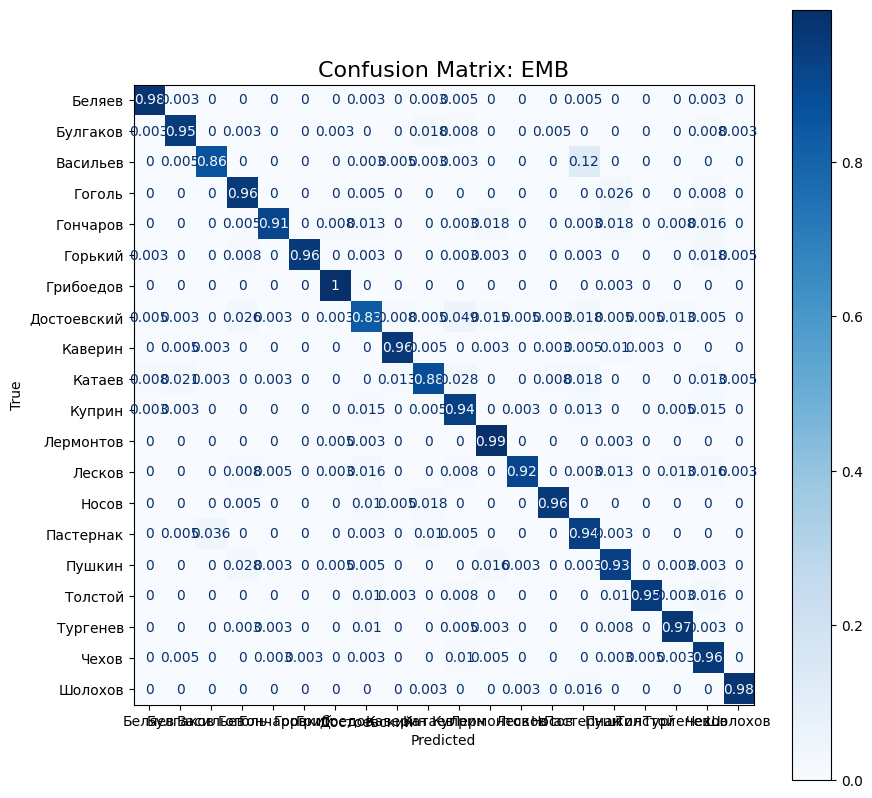

--------------------------------------------------------------------------------
Accuracy: 0.9412
Беляев               → 0.9793
Булгаков             → 0.9509
Васильев             → 0.8630
Гоголь               → 0.9612
Гончаров             → 0.9096
Горький              → 0.9561
Грибоедов            → 0.9974
Достоевский          → 0.8299
Каверин              → 0.9638
Катаев               → 0.8811
Куприн               → 0.9381
Лермонтов            → 0.9897
Лесков               → 0.9147
Носов                → 0.9612
Пастернак            → 0.9381
Пушкин               → 0.9328
Толстой              → 0.9509
Тургенев             → 0.9664
Чехов                → 0.9612
Шолохов              → 0.9793

Mean class accuracy: 0.9413


In [30]:
model_emb = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LEN
    ),

    SpatialDropout1D(0.3),

    GlobalAveragePooling1D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(len(le.classes_), activation='softmax')
])

compile_train_eval_model(model_emb,
                         X_train, y_train,
                         X_test, y_test,
                         class_labels=le.classes_,
                         title='EMB')

In [31]:
model_emb.save('model_emb_ultra_pro.keras')